In [2]:
# =============================================================================
# TCC — Caracterização Não Supervisionada de Perturbações Elétricas
# Rafael Benzaquem Neto | UFRR — ECAI 4.0
#
# MÓDULO 1 — Pré-processamento dos Dados (Seção 4.3.1)
# Pipeline: Ingestão → Validação → Normalização p.u. → Janelamento → Export
# =============================================================================
# Compatível com Google Colab. Execute célula a célula (▶).
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 1 — Instalação de dependências
# ─────────────────────────────────────────────────────────────────────────────
#!pip install scipy matplotlib numpy pandas --quiet

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import glob
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
#from google.colab import drive

# Reprodutibilidade
np.random.seed(42)

print("✅ Bibliotecas carregadas com sucesso.")

✅ Bibliotecas carregadas com sucesso.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 3 — Configurações globais do sistema elétrico
#            Ajuste conforme os parâmetros da sua subestação
# ─────────────────────────────────────────────────────────────────────────────

# --- Parâmetros do sistema ---
FREQ_NOMINAL_HZ   = 50.0          # Frequência nominal [Hz] (altere para 60.0 se necessário)
SAMPLES_PER_CYCLE = 24            # Amostras por ciclo (confirmado na estrutura do .mat)
NUM_CYCLES        = 16            # Duração da janela em ciclos (IEEE Std 1159:2019 — 10 a 16 ciclos)
WINDOW_SIZE       = SAMPLES_PER_CYCLE * NUM_CYCLES  # = 384 amostras

# Tensão nominal de fase (pico) — kV. Usado para normalização p.u.
# Exemplo: sistema 110 kV (linha) → fase pico = 110/√3 × √2 ≈ 89.8 kV
# Ajuste abaixo conforme o nível de tensão real da subestação.
V_NOMINAL_PEAK_KV = 98.0          # kV (estimado do máximo observado nos dados)

# Canais de tensão e corrente trifásica presentes no .mat
VOLTAGE_KEYS   = ['matXVa', 'matXVb', 'matXVc']   # Tensões de fase A, B, C
CURRENT_KEYS   = ['matXIa', 'matXIb', 'matXIc']   # Correntes de fase A, B, C
AUX_KEY        = 'matAux'                           # Metadados por evento

# Índices interpretados de matAux (baseado na inspeção dos dados)
AUX_COL_NAMES = [
    'tipo_evento',       # col 0  — código numérico do tipo de perturbação
    'amp_max_pos',       # col 1  — amplitude máxima positiva (p.u.)
    'amp_max_neg',       # col 2  — amplitude máxima negativa (p.u.)
    'V_rms_max',         # col 3  — tensão RMS máxima (p.u.)
    'V_rms_min',         # col 4  — tensão RMS mínima (p.u.)
    'ts_inicio',         # col 5  — timestamp de início (ms)
    'ts_fim',            # col 6  — timestamp de fim (ms)
    'duracao_ciclos',    # col 7  — duração em ciclos
    'duracao_ms',        # col 8  — duração em ms
    'freq_medida_hz',    # col 9  — frequência medida (Hz)
    'n_amostras',        # col 10 — número de amostras
    'n_ciclos_pre',      # col 11 — ciclos de pré-falta
    'n_ciclos_pos',      # col 12 — ciclos de pós-falta
    'flag_A',            # col 13 — flag fase A
    'flag_B',            # col 14 — flag fase B
    'flag_C',            # col 15 — flag fase C
    'flag_N',            # col 16 — flag neutro
    'flag_extra',        # col 17
    'ts_pico',           # col 18 — timestamp do pico
    'codigo_evento',     # col 19 — código interno do evento
]

# Diretório de dados — adapte ao caminho no Colab/Drive
#drive.mount('/content/drive')
DATA_DIR    = './0_dados_brutos'
OUTPUT_DIR  = './1_dados_preprocessados'
SINGLE_FILE = None  # Defina como path de um arquivo único para testes isolados

# Criar diretório de saída se não existir
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✅ Configurações carregadas.")
print(f"   Janela: {NUM_CYCLES} ciclos × {SAMPLES_PER_CYCLE} amostras = {WINDOW_SIZE} amostras")
print(f"   Tensão nominal pico: {V_NOMINAL_PEAK_KV} kV")
print(f"   Saída em: {OUTPUT_DIR}")

✅ Configurações carregadas.
   Janela: 16 ciclos × 24 amostras = 384 amostras
   Tensão nominal pico: 98.0 kV
   Saída em: ./1_dados_preprocessados


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 4 — Funções de carregamento e validação
# ─────────────────────────────────────────────────────────────────────────────

def carregar_mat(caminho_arquivo: str) -> dict | None:
    """
    Carrega um arquivo .mat (formato Detection) e retorna um dicionário
    com arrays NumPy para cada canal.

    Retorna None se o arquivo for inválido ou corrompido.
    """
    try:
        mat = scipy.io.loadmat(caminho_arquivo)
    except Exception as e:
        print(f"  ⚠️  Erro ao carregar '{caminho_arquivo}': {e}")
        return None

    dados = {}
    chaves_esperadas = VOLTAGE_KEYS + CURRENT_KEYS + [AUX_KEY]

    for chave in chaves_esperadas:
        if chave not in mat:
            print(f"  ⚠️  Chave ausente: '{chave}' em '{Path(caminho_arquivo).name}'")
            return None
        dados[chave] = mat[chave]

    return dados


def validar_evento(sinal: np.ndarray, idx_evento: int,
                   nome_canal: str, nome_arquivo: str) -> bool:
    """
    Valida um único evento (linha do array):
      1. Tamanho correto (WINDOW_SIZE amostras)
      2. Sem valores NaN ou Inf
      3. Sinal não nulo (variância > 0)

    Retorna True se o evento passa em todos os critérios.
    """
    if sinal.shape[0] != WINDOW_SIZE:
        print(f"    ✗ [{nome_arquivo}] Evento {idx_evento} — {nome_canal}: "
              f"tamanho incorreto ({sinal.shape[0]} ≠ {WINDOW_SIZE})")
        return False

    if not np.isfinite(sinal).all():
        print(f"    ✗ [{nome_arquivo}] Evento {idx_evento} — {nome_canal}: "
              f"contém NaN ou Inf")
        return False

    if np.var(sinal) == 0:
        print(f"    ✗ [{nome_arquivo}] Evento {idx_evento} — {nome_canal}: "
              f"sinal constante (variância = 0)")
        return False

    return True


def validar_arquivo(dados: dict, nome_arquivo: str) -> np.ndarray:
    """
    Verifica evento a evento em todos os canais de tensão.
    Retorna máscara booleana indicando quais eventos são válidos.
    """
    n_eventos = dados[VOLTAGE_KEYS[0]].shape[0]
    mascara_validos = np.ones(n_eventos, dtype=bool)

    for idx in range(n_eventos):
        for chave in VOLTAGE_KEYS:
            sinal = dados[chave][idx]
            if not validar_evento(sinal, idx, chave, nome_arquivo):
                mascara_validos[idx] = False
                break  # já descarta o evento — não precisa checar outros canais

    n_validos  = mascara_validos.sum()
    n_removidos = n_eventos - n_validos
    if n_removidos > 0:
        print(f"  ℹ️  {nome_arquivo}: {n_removidos} evento(s) removido(s) por inconsistência.")

    return mascara_validos


print("✅ Funções de carregamento e validação definidas.")

✅ Funções de carregamento e validação definidas.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 5 — Normalização p.u. (per unit)
#
# Conforme IEEE Std 1159:2019 e Seção 4.3.1 do TCC:
#   v_pu[n] = v_inst[n] / V_nominal_pico
#
# Preserva magnitude real da tensão remanescente (retained voltage),
# essencial para diferenciar:
#   • Sags:          0,1 a 0,9 p.u.
#   • Swells:        1,1 a 1,8 p.u.
#   • Interrupções:  < 0,1 p.u.
# ─────────────────────────────────────────────────────────────────────────────

def normalizar_pu(sinais: np.ndarray,
                  v_nominal_pico: float = V_NOMINAL_PEAK_KV) -> np.ndarray:
    """
    Normaliza um array de sinais de tensão para por unidade (p.u.).

    Parâmetros
    ----------
    sinais        : np.ndarray shape (N_eventos, WINDOW_SIZE) — tensão em kV
    v_nominal_pico: float — tensão nominal de pico em kV

    Retorna
    -------
    np.ndarray shape (N_eventos, WINDOW_SIZE) — tensão normalizada em p.u.
    """
    return sinais / v_nominal_pico


def calcular_vrms_por_ciclo(sinal_pu: np.ndarray,
                             spc: int = SAMPLES_PER_CYCLE) -> np.ndarray:
    """
    Calcula o valor RMS de cada ciclo de um sinal normalizado em p.u.

    Parâmetros
    ----------
    sinal_pu : np.ndarray shape (WINDOW_SIZE,) — sinal normalizado
    spc      : int — amostras por ciclo

    Retorna
    -------
    np.ndarray shape (NUM_CYCLES,) — RMS por ciclo
    """
    n_ciclos = len(sinal_pu) // spc
    rms = np.zeros(n_ciclos)
    for i in range(n_ciclos):
        segmento = sinal_pu[i * spc:(i + 1) * spc]
        rms[i] = np.sqrt(np.mean(segmento ** 2))
    return rms


print("✅ Funções de normalização p.u. definidas.")

✅ Funções de normalização p.u. definidas.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 6 — Janelamento deslizante (sliding window)
#
# Para sinais que ultrapassem NUM_CYCLES ciclos, extrai janelas
# sobrepostas de tamanho fixo WINDOW_SIZE, com passo configurável.
# Garante uniformidade na entrada do modelo de Deep Learning.
# ─────────────────────────────────────────────────────────────────────────────

def janelamento_deslizante(sinal: np.ndarray,
                            tamanho_janela: int = WINDOW_SIZE,
                            passo: int = None) -> np.ndarray:
    """
    Aplica janelamento deslizante a um sinal unidimensional.

    Parâmetros
    ----------
    sinal         : np.ndarray shape (T,) — sinal temporal
    tamanho_janela: int — número de amostras por janela
    passo         : int — deslocamento entre janelas (default = tamanho_janela, sem sobreposição)

    Retorna
    -------
    np.ndarray shape (N_janelas, tamanho_janela)
    """
    if passo is None:
        passo = tamanho_janela  # janelas sem sobreposição por padrão

    n_amostras = len(sinal)
    if n_amostras < tamanho_janela:
        raise ValueError(f"Sinal ({n_amostras} amostras) menor que a janela ({tamanho_janela}).")

    indices_inicio = range(0, n_amostras - tamanho_janela + 1, passo)
    janelas = np.array([sinal[i:i + tamanho_janela] for i in indices_inicio])
    return janelas


print("✅ Função de janelamento deslizante definida.")

✅ Função de janelamento deslizante definida.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 7 — Pipeline principal de pré-processamento
# ─────────────────────────────────────────────────────────────────────────────

def preprocessar_arquivo(caminho_arquivo: str,
                          v_nominal_pico: float = V_NOMINAL_PEAK_KV
                          ) -> tuple[np.ndarray, np.ndarray, pd.DataFrame] | None:
    """
    Executa o pipeline completo de pré-processamento em um único arquivo .mat.

    Etapas:
      1. Carregamento
      2. Validação e filtragem de registros corrompidos
      3. Normalização p.u. das tensões trifásicas
      4. Empilhamento dos canais → tensor (N, W, C)
      5. Extração dos metadados (matAux)

    Parâmetros
    ----------
    caminho_arquivo : str — caminho para o arquivo .mat
    v_nominal_pico  : float — tensão nominal pico em kV

    Retorna
    -------
    X_pu       : np.ndarray shape (N_validos, WINDOW_SIZE, 3)
                 Tensor de sinais trifásicos normalizados em p.u.
    X_raw_kv   : np.ndarray shape (N_validos, WINDOW_SIZE, 3)
                 Tensor de sinais brutos em kV (para referência/visualização)
    df_aux     : pd.DataFrame shape (N_validos, len(AUX_COL_NAMES))
                 Metadados de cada evento válido
    """
    nome = Path(caminho_arquivo).name
    print(f"\n📂 Processando: {nome}")

    # --- 1. Carregamento ---
    dados = carregar_mat(caminho_arquivo)
    if dados is None:
        return None

    n_total = dados[VOLTAGE_KEYS[0]].shape[0]
    print(f"   Eventos carregados: {n_total}")

    # --- 2. Validação ---
    mascara = validar_arquivo(dados, nome)
    n_validos = mascara.sum()
    print(f"   Eventos válidos: {n_validos} / {n_total}")

    if n_validos == 0:
        print(f"   ⚠️  Nenhum evento válido. Arquivo ignorado.")
        return None

    # --- 3. Normalização p.u. e empilhamento trifásico ---
    canais_pu  = []
    canais_raw = []

    for chave in VOLTAGE_KEYS:
        sinal_raw = dados[chave][mascara]          # (N_validos, 384) — kV
        sinal_pu  = normalizar_pu(sinal_raw, v_nominal_pico)
        canais_pu.append(sinal_pu)
        canais_raw.append(sinal_raw)

    # shape final: (N_validos, WINDOW_SIZE, 3)
    X_pu     = np.stack(canais_pu,  axis=-1)
    X_raw_kv = np.stack(canais_raw, axis=-1)

    # --- 4. Metadados ---
    aux_filtrado = dados[AUX_KEY][mascara]  # (N_validos, 20)
    n_colunas = min(len(AUX_COL_NAMES), aux_filtrado.shape[1])
    df_aux = pd.DataFrame(
        aux_filtrado[:, :n_colunas],
        columns=AUX_COL_NAMES[:n_colunas]
    )
    df_aux['arquivo_origem'] = nome

    print(f"   ✅ Shape do tensor p.u.: {X_pu.shape}  (N_eventos × amostras × fases)")
    return X_pu, X_raw_kv, df_aux


def preprocessar_diretorio(diretorio: str,
                            v_nominal_pico: float = V_NOMINAL_PEAK_KV
                            ) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Aplica o pipeline em todos os arquivos .mat de um diretório e
    concatena os resultados em tensores únicos.

    Retorna
    -------
    X_pu_total   : np.ndarray shape (N_total, WINDOW_SIZE, 3)
    X_raw_total  : np.ndarray shape (N_total, WINDOW_SIZE, 3)
    df_aux_total : pd.DataFrame shape (N_total, n_colunas_aux)
    """
    arquivos = sorted(glob.glob(os.path.join(diretorio, '**', '*.mat'), recursive=True))
   # arquivos = sorted(glob.glob(os.path.join(diretorio, '*.mat')))
    print(f"🗂️  {len(arquivos)} arquivo(s) .mat encontrado(s) em '{diretorio}'")

    lista_pu, lista_raw, lista_aux = [], [], []

    for arq in arquivos:
        resultado = preprocessar_arquivo(arq, v_nominal_pico)
        if resultado is None:
            continue
        X_pu, X_raw, df_aux = resultado
        lista_pu.append(X_pu)
        lista_raw.append(X_raw)
        lista_aux.append(df_aux)

    if not lista_pu:
        raise RuntimeError("Nenhum arquivo válido encontrado no diretório.")

    X_pu_total  = np.concatenate(lista_pu,  axis=0)
    X_raw_total = np.concatenate(lista_raw, axis=0)
    df_total    = pd.concat(lista_aux, ignore_index=True)

    print(f"\n{'='*55}")
    print(f"📊 RESUMO FINAL DO PRÉ-PROCESSAMENTO")
    print(f"   Total de eventos válidos : {X_pu_total.shape[0]}")
    print(f"   Shape do tensor p.u.     : {X_pu_total.shape}")
    print(f"   Faixa p.u. (Va)          : [{X_pu_total[:,:,0].min():.3f}, {X_pu_total[:,:,0].max():.3f}]")
    print(f"{'='*55}")

    return X_pu_total, X_raw_total, df_total


print("✅ Pipeline principal definido.")

✅ Pipeline principal definido.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 8 — Execução do pipeline
# ─────────────────────────────────────────────────────────────────────────────

# Escolha o modo de execução:
#   A) Arquivo único (para testes)     → defina SINGLE_FILE
#   B) Diretório completo (produção)   → defina DATA_DIR

# >>> MODO A — arquivo único (para testar com o Q0000833_detection.mat) <<<
# Descomente e ajuste o caminho abaixo para rodar no Colab:
#
# SINGLE_FILE = '/content/Q0000833_detection.mat'
# resultado = preprocessar_arquivo(SINGLE_FILE)
# if resultado:
#     X_pu, X_raw_kv, df_aux = resultado

# >>> MODO B — diretório completo (produção) <<<
# Descomente abaixo para processar todos os .mat de uma pasta:
#
X_pu, X_raw_kv, df_aux = preprocessar_diretorio(DATA_DIR)

# ─────────── EXECUÇÃO DE DEMONSTRAÇÃO (sem Drive — arquivo local) ──────────
# Se você fez upload manual do arquivo no Colab, use:
#SINGLE_FILE = '0_dados_brutos/Q0000833_detection.mat'

#import os
#if os.path.exists(SINGLE_FILE):
#    resultado = preprocessar_arquivo(SINGLE_FILE)
#    if resultado:
#        X_pu, X_raw_kv, df_aux = resultado
#else:
#    print(f"⚠️  Arquivo não encontrado em '{SINGLE_FILE}'.")
#    print("   Faça o upload do arquivo ou monte o Google Drive.")
#    print("   Para montar o Drive, execute: from google.colab import drive; drive.mount('/content/drive')")

🗂️  378 arquivo(s) .mat encontrado(s) em './0_dados_brutos'

📂 Processando: Q0000833_detection.mat
   Eventos carregados: 48
   Eventos válidos: 48 / 48
   ✅ Shape do tensor p.u.: (48, 384, 3)  (N_eventos × amostras × fases)

📂 Processando: Q0000834_detection.mat
   Eventos carregados: 44
   Eventos válidos: 44 / 44
   ✅ Shape do tensor p.u.: (44, 384, 3)  (N_eventos × amostras × fases)

📂 Processando: Q0000835_detection.mat
   Eventos carregados: 27
   Eventos válidos: 27 / 27
   ✅ Shape do tensor p.u.: (27, 384, 3)  (N_eventos × amostras × fases)

📂 Processando: Q0000836_detection.mat
   Eventos carregados: 14
   Eventos válidos: 14 / 14
   ✅ Shape do tensor p.u.: (14, 384, 3)  (N_eventos × amostras × fases)

📂 Processando: Q0000837_detection.mat
   Eventos carregados: 15
   Eventos válidos: 15 / 15
   ✅ Shape do tensor p.u.: (15, 384, 3)  (N_eventos × amostras × fases)

📂 Processando: Q0000838_detection.mat
   Eventos carregados: 11
   Eventos válidos: 11 / 11
   ✅ Shape do tensor p

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 9 — Salvar dados pré-processados
# ─────────────────────────────────────────────────────────────────────────────

def salvar_preprocessado(X_pu: np.ndarray,
                          X_raw_kv: np.ndarray,
                          df_aux: pd.DataFrame,
                          diretorio_saida: str = OUTPUT_DIR,
                          prefixo: str = 'dataset') -> None:
    """
    Persiste os dados pré-processados no disco:
      • {prefixo}_X_pu.npy        — tensor normalizado p.u.
      • {prefixo}_X_raw_kv.npy   — tensor bruto em kV
      • {prefixo}_metadata.csv   — metadados dos eventos
    """
    os.makedirs(diretorio_saida, exist_ok=True)

    path_pu  = os.path.join(diretorio_saida, f'{prefixo}_X_pu.npy')
    path_raw = os.path.join(diretorio_saida, f'{prefixo}_X_raw_kv.npy')
    path_csv = os.path.join(diretorio_saida, f'{prefixo}_metadata.csv')

    np.save(path_pu,  X_pu)
    np.save(path_raw, X_raw_kv)
    df_aux.to_csv(path_csv, index=False)

    print(f"\n💾 Dados salvos em '{diretorio_saida}':")
    print(f"   • {Path(path_pu).name}   — shape {X_pu.shape}")
    print(f"   • {Path(path_raw).name}  — shape {X_raw_kv.shape}")
    print(f"   • {Path(path_csv).name}  — {len(df_aux)} registros")


def carregar_preprocessado(diretorio: str,
                            prefixo: str = 'dataset'
                            ) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Recarrega os dados pré-processados salvos em disco."""
    X_pu    = np.load(os.path.join(diretorio, f'{prefixo}_X_pu.npy'))
    X_raw   = np.load(os.path.join(diretorio, f'{prefixo}_X_raw_kv.npy'))
    df_aux  = pd.read_csv(os.path.join(diretorio, f'{prefixo}_metadata.csv'))
    print(f"✅ Dados recarregados: {X_pu.shape[0]} eventos, shape {X_pu.shape}")
    return X_pu, X_raw, df_aux


# Salva se o pipeline rodou com sucesso
try:
    salvar_preprocessado(X_pu, X_raw_kv, df_aux, OUTPUT_DIR)
except NameError:
    print("⚠️  Execute a célula anterior (Célula 8) para gerar os dados antes de salvar.")

print("✅ Funções de I/O definidas.")


💾 Dados salvos em './1_dados_preprocessados':
   • dataset_X_pu.npy   — shape (12092, 384, 3)
   • dataset_X_raw_kv.npy  — shape (12092, 384, 3)
   • dataset_metadata.csv  — 12092 registros
✅ Funções de I/O definidas.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 10 — Visualização e diagnóstico
# ─────────────────────────────────────────────────────────────────────────────

def plotar_evento(X_pu: np.ndarray,
                  df_aux: pd.DataFrame,
                  idx_evento: int = 0,
                  spc: int = SAMPLES_PER_CYCLE,
                  freq: float = FREQ_NOMINAL_HZ) -> None:
    """
    Plota as formas de onda trifásicas em p.u. de um evento específico,
    junto com a evolução do RMS por ciclo e os metadados principais.
    """
    sinal   = X_pu[idx_evento]              # (384, 3)
    meta    = df_aux.iloc[idx_evento]
    n_amostras = sinal.shape[0]
    dt      = 1 / (spc * freq)             # intervalo de amostragem [s]
    t_ms    = np.arange(n_amostras) * dt * 1e3  # eixo de tempo em ms
    fases   = ['Va (p.u.)', 'Vb (p.u.)', 'Vc (p.u.)']
    cores   = ['#e63946', '#457b9d', '#2a9d8f']

    fig = plt.figure(figsize=(14, 8))
    fig.suptitle(
        f"Evento #{idx_evento} — {meta.get('arquivo_origem', 'N/A')}\n"
        f"Tipo: {int(meta.get('tipo_evento', -1))}  |  "
        f"Duração: {meta.get('duracao_ms', 0):.1f} ms  |  "
        f"Vmin p.u.: {meta.get('V_rms_min', 0):.3f}  |  "
        f"Vmax p.u.: {meta.get('V_rms_max', 0):.3f}",
        fontsize=12, fontweight='bold'
    )

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # --- Linha 1: formas de onda trifásicas ---
    for col, (fase, cor) in enumerate(zip(fases, cores)):
        ax = fig.add_subplot(gs[0, col])
        ax.plot(t_ms, sinal[:, col], color=cor, linewidth=0.8)
        ax.axhline( 0.9, color='orange', linewidth=0.8, linestyle='--', label='0.9 p.u.')
        ax.axhline(-0.9, color='orange', linewidth=0.8, linestyle='--')
        ax.axhline( 1.1, color='red',    linewidth=0.8, linestyle='--', label='1.1 p.u.')
        ax.axhline(-1.1, color='red',    linewidth=0.8, linestyle='--')
        ax.set_title(fase, fontsize=10)
        ax.set_xlabel('Tempo (ms)', fontsize=8)
        ax.set_ylabel('Tensão (p.u.)', fontsize=8)
        ax.set_ylim(-1.5, 1.5)
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.legend(fontsize=7, loc='upper right')

    # --- Linha 2: RMS por ciclo para cada fase ---
    for col, (fase, cor) in enumerate(zip(fases, cores)):
        ax = fig.add_subplot(gs[1, col])
        rms = calcular_vrms_por_ciclo(sinal[:, col], spc)
        ciclos = np.arange(1, len(rms) + 1)
        ax.bar(ciclos, rms, color=cor, alpha=0.75, edgecolor='black', linewidth=0.4)
        ax.axhline(0.9, color='orange', linewidth=1.0, linestyle='--', label='Sag (0.9)')
        ax.axhline(1.1, color='red',    linewidth=1.0, linestyle='--', label='Swell (1.1)')
        ax.axhline(0.1, color='purple', linewidth=1.0, linestyle='--', label='Interr. (0.1)')
        ax.set_title(f'RMS por ciclo — {fase}', fontsize=10)
        ax.set_xlabel('Ciclo', fontsize=8)
        ax.set_ylabel('V_rms (p.u.)', fontsize=8)
        ax.set_ylim(0, 1.4)
        ax.set_xticks(ciclos)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(fontsize=7, loc='upper right')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(os.path.join(OUTPUT_DIR, f'evento_{idx_evento:04d}.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    print(f"   📈 Gráfico salvo: evento_{idx_evento:04d}.png")


def plotar_distribuicao_vmin(X_pu: np.ndarray,
                              spc: int = SAMPLES_PER_CYCLE) -> None:
    """
    Plota o histograma da tensão RMS mínima (ciclo mais perturbado)
    de todos os eventos, com marcadores das categorias IEEE Std 1159.
    """
    # Tensão RMS mínima entre todos os ciclos e fases
    v_min_list = []
    for i in range(X_pu.shape[0]):
        rms_ciclos = np.array([
            calcular_vrms_por_ciclo(X_pu[i, :, f], spc) for f in range(3)
        ])  # (3, NUM_CYCLES)
        v_min_list.append(rms_ciclos.min())

    v_min = np.array(v_min_list)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(v_min, bins=40, color='#457b9d', edgecolor='black', alpha=0.8)
    ax.axvline(0.10, color='purple', linewidth=1.5, linestyle='--', label='Interrupção < 0.1 p.u.')
    ax.axvline(0.90, color='orange', linewidth=1.5, linestyle='--', label='Limite Sag ≤ 0.9 p.u.')
    ax.axvline(1.10, color='red',    linewidth=1.5, linestyle='--', label='Limite Swell ≥ 1.1 p.u.')
    ax.set_title('Distribuição da Tensão RMS Mínima — Todos os Eventos\n'
                 '(Referência: IEEE Std 1159:2019)', fontsize=12)
    ax.set_xlabel('V_rms mínimo (p.u.)', fontsize=11)
    ax.set_ylabel('Frequência', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'distribuicao_vmin.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print("   📈 Histograma salvo: distribuicao_vmin.png")


def resumo_estatistico(X_pu: np.ndarray, df_aux: pd.DataFrame) -> pd.DataFrame:
    """
    Gera um DataFrame com estatísticas descritivas por evento:
    V_rms_min, V_rms_max, amplitude_pico_pos, amplitude_pico_neg.
    """
    stats = []
    for i in range(X_pu.shape[0]):
        sinal = X_pu[i]  # (384, 3)
        rms_all = np.array([
            calcular_vrms_por_ciclo(sinal[:, f]) for f in range(3)
        ])
        stats.append({
            'evento_idx'     : i,
            'arquivo'        : df_aux.iloc[i].get('arquivo_origem', ''),
            'tipo_evento'    : df_aux.iloc[i].get('tipo_evento', -1),
            'V_rms_min_pu'   : rms_all.min(),
            'V_rms_max_pu'   : rms_all.max(),
            'amp_pico_pos_pu': sinal.max(),
            'amp_pico_neg_pu': sinal.min(),
            # Classificação heurística IEEE 1159 (baseada no ciclo mais perturbado)
            'classe_heuristica': (
                'interrupção' if rms_all.min() < 0.10 else
                'sag'         if rms_all.min() < 0.90 else
                'swell'       if rms_all.max() > 1.10 else
                'normal/outro'
            )
        })

    df_stats = pd.DataFrame(stats)
    print("\n📊 Resumo estatístico (primeiras 10 linhas):")
    print(df_stats.head(10).to_string(index=False))
    print(f"\n   Distribuição de classes heurísticas:")
    print(df_stats['classe_heuristica'].value_counts().to_string())
    return df_stats


print("✅ Funções de visualização e diagnóstico definidas.")

✅ Funções de visualização e diagnóstico definidas.


C:\Users\rafae\AppData\Local\Temp\ipykernel_4592\2553097365.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


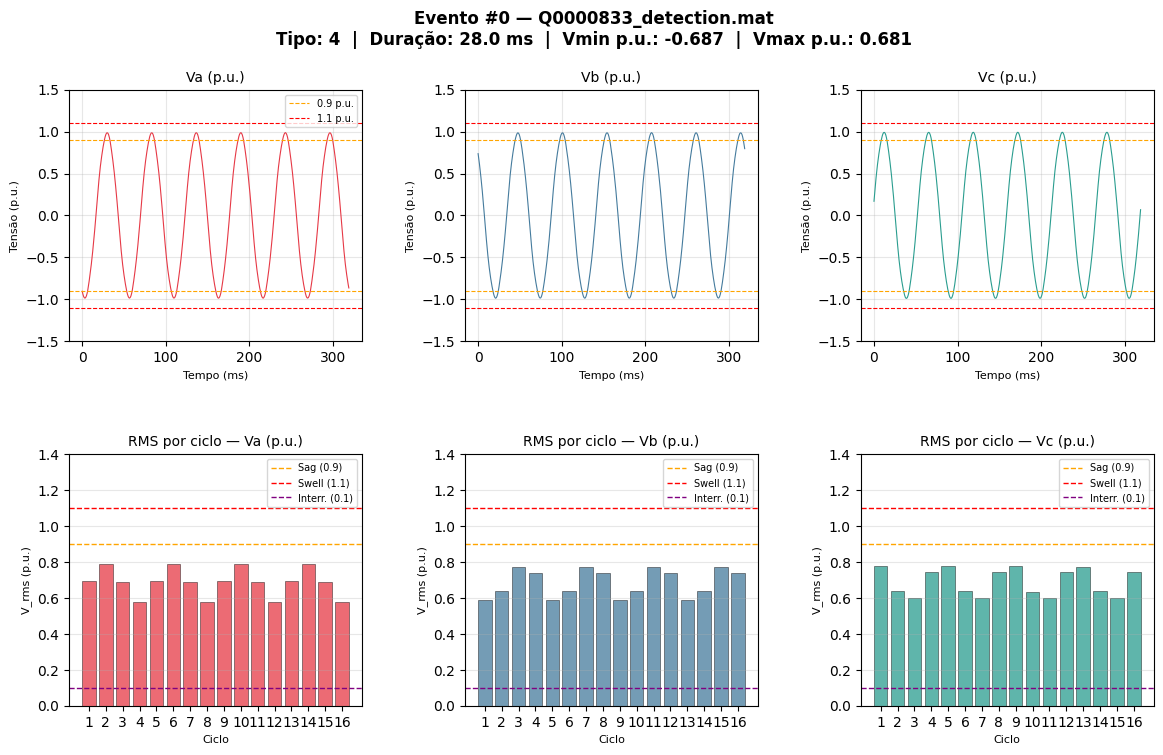

   📈 Gráfico salvo: evento_0000.png


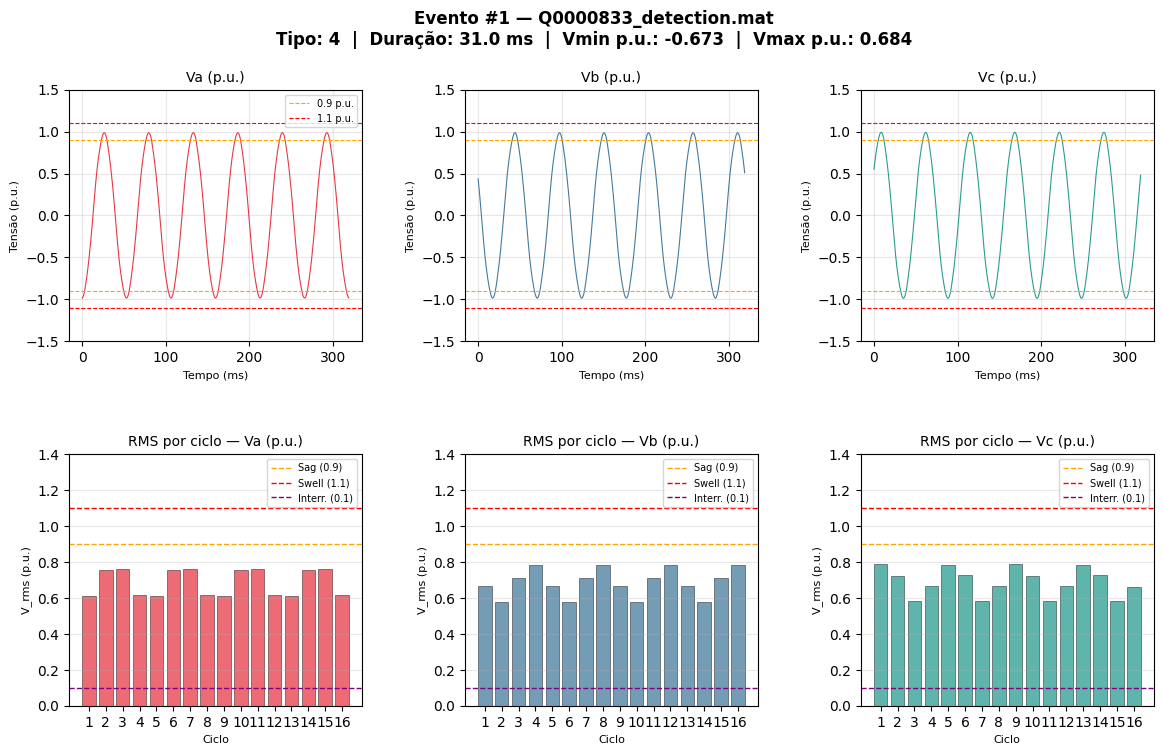

   📈 Gráfico salvo: evento_0001.png


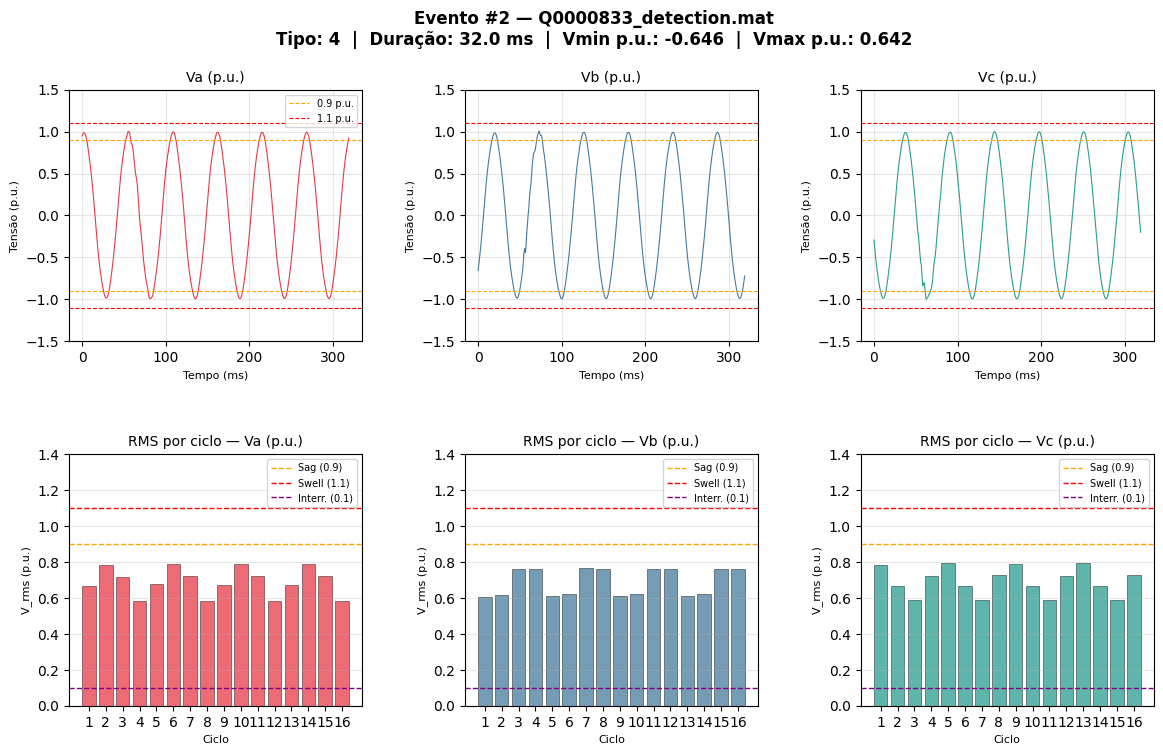

   📈 Gráfico salvo: evento_0002.png


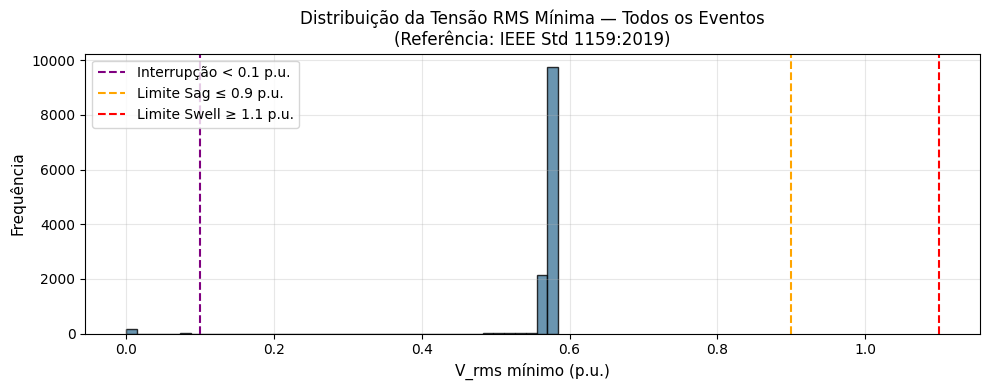

   📈 Histograma salvo: distribuicao_vmin.png

📊 Resumo estatístico (primeiras 10 linhas):
 evento_idx                arquivo  tipo_evento  V_rms_min_pu  V_rms_max_pu  amp_pico_pos_pu  amp_pico_neg_pu classe_heuristica
          0 Q0000833_detection.mat          4.0      0.575237      0.787332         0.991887        -0.988914               sag
          1 Q0000833_detection.mat          4.0      0.578181      0.787289         0.992217        -0.989575               sag
          2 Q0000833_detection.mat          4.0      0.580546      0.792540         1.004438        -0.998823               sag
          3 Q0000833_detection.mat          4.0      0.576969      0.789639         0.996181        -0.993208               sag
          4 Q0000833_detection.mat          4.0      0.578555      0.791276         0.996842        -0.993539               sag
          5 Q0000833_detection.mat          4.0      0.574507      0.789232         0.995851        -0.992548               sag
          6 Q0

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 11 — Executar visualizações
# ─────────────────────────────────────────────────────────────────────────────

try:
    # Plota os 3 primeiros eventos como diagnóstico
    for idx in range(min(3, X_pu.shape[0])):
        plotar_evento(X_pu, df_aux, idx_evento=idx)

    # Histograma geral
    plotar_distribuicao_vmin(X_pu)

    # Tabela estatística
    df_stats = resumo_estatistico(X_pu, df_aux)

    # Salvar estatísticas
    path_stats = os.path.join(OUTPUT_DIR, 'estatisticas_eventos.csv')
    df_stats.to_csv(path_stats, index=False)
    print(f"\n💾 Estatísticas salvas em: {path_stats}")

except NameError:
    print("⚠️  Execute as células 8 e 9 antes de gerar visualizações.")

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 12 — Preparar tensor para entrada no CAE (próxima etapa — Seção 4.3.2)
# ─────────────────────────────────────────────────────────────────────────────

def preparar_tensor_cae(X_pu: np.ndarray) -> np.ndarray:
    """
    Formata o tensor p.u. para entrada do Autoencoder Convolucional (CAE).

    O CAE espera shape: (N, timesteps, canais)
      N         = número de eventos
      timesteps = WINDOW_SIZE (384 amostras)
      canais    = 3 (fases Va, Vb, Vc)

    O tensor já está nesse formato após o pré-processamento.
    Esta função valida o shape e garante dtype float32 (otimizado para GPU).

    Retorna
    -------
    np.ndarray shape (N, 384, 3), dtype float32
    """
    assert X_pu.ndim == 3,          f"Esperado 3D, obtido {X_pu.ndim}D"
    assert X_pu.shape[1] == WINDOW_SIZE, f"Esperado {WINDOW_SIZE} timesteps, obtido {X_pu.shape[1]}"
    assert X_pu.shape[2] == 3,      f"Esperado 3 canais (fases), obtido {X_pu.shape[2]}"

    X_cae = X_pu.astype(np.float32)

    print(f"\n🔧 Tensor pronto para o CAE:")
    print(f"   Shape : {X_cae.shape}  (N_eventos × timesteps × fases)")
    print(f"   Dtype : {X_cae.dtype}")
    print(f"   Range : [{X_cae.min():.4f}, {X_cae.max():.4f}] p.u.")
    print(f"\n   ➡️  Próxima etapa: Treinamento do Autoencoder Convolucional (Seção 4.3.2)")
    return X_cae


try:
    X_cae = preparar_tensor_cae(X_pu)
    np.save(os.path.join(OUTPUT_DIR, 'X_cae_input.npy'), X_cae)
    print(f"   💾 Tensor CAE salvo: X_cae_input.npy")
except NameError:
    print("⚠️  Execute a célula 8 primeiro para gerar X_pu.")

# ─────────────────────────────────────────────────────────────────────────────
# FIM DO MÓDULO 1 — Pré-processamento
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("✅ Módulo 1 — Pré-processamento concluído.")
print("   Arquivos gerados em:", OUTPUT_DIR)
print("   Próximo módulo: Autoencoder Convolucional (CAE)")
print("="*55)


🔧 Tensor pronto para o CAE:
   Shape : (12092, 384, 3)  (N_eventos × timesteps × fases)
   Dtype : float32
   Range : [-2.0845, 1.7341] p.u.

   ➡️  Próxima etapa: Treinamento do Autoencoder Convolucional (Seção 4.3.2)
   💾 Tensor CAE salvo: X_cae_input.npy

✅ Módulo 1 — Pré-processamento concluído.
   Arquivos gerados em: ./1_dados_preprocessados
   Próximo módulo: Autoencoder Convolucional (CAE)
